<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv("hneel_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,worldwidetelescope_pywwt,00160f35b811acb815ef8f83be5b8b08450699cc,Peter Williams <peter@newton.cx>,1735501022,ci/azure-build-and-test.yml: update to macos-1...,2024-12
1,worldwidetelescope_pywwt,003a914e43bb1580e4388a9e1c0324dba8d13f88,John ZuHone <jzuhone@gmail.com>,1390417549,Finished up docs for WWTClient\n,2014-01
2,worldwidetelescope_pywwt,00416e07dc7f59cbc38579b4d35ec78377a75c59,Thomas Robitaille <thomas.robitaille@gmail.com>,1544716470,Fix setting of color,2018-12
3,worldwidetelescope_pywwt,007773c9c9201926be2f58a7cd7776b89ae70393,O . O <ojustino@users.noreply.github.com>,1535649299,Gave ability to list and delete FOVs\n,2018-08
4,worldwidetelescope_pywwt,0087a6db8e34c0463b11a98e6d5249daa4d72750,Peter Williams <peter@newton.cx>,1602972118,Tidying to get the Jupyter bits working\n\nAnd...,2020-10


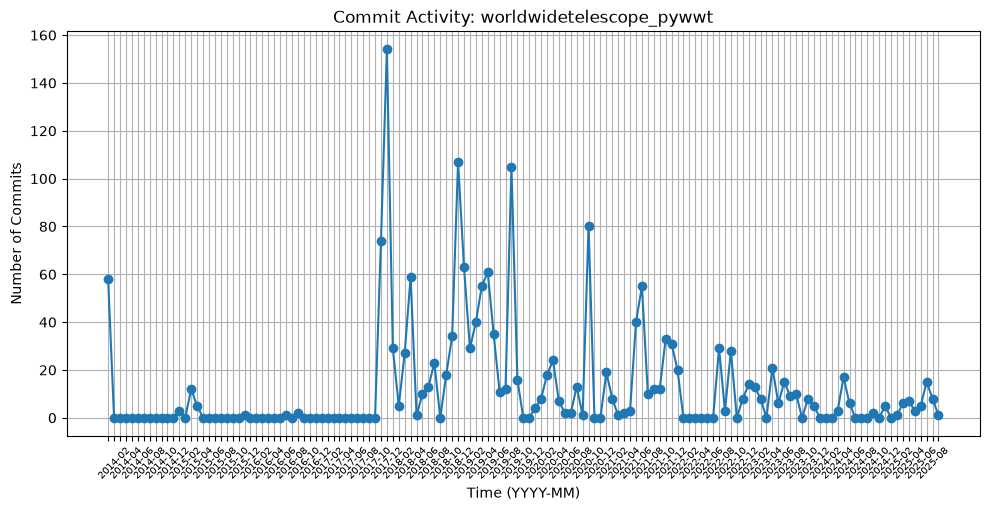

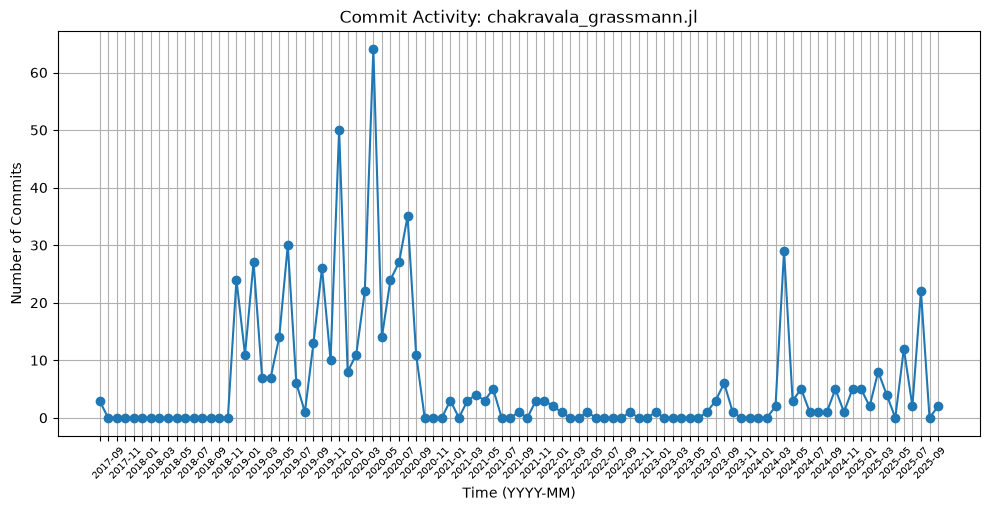

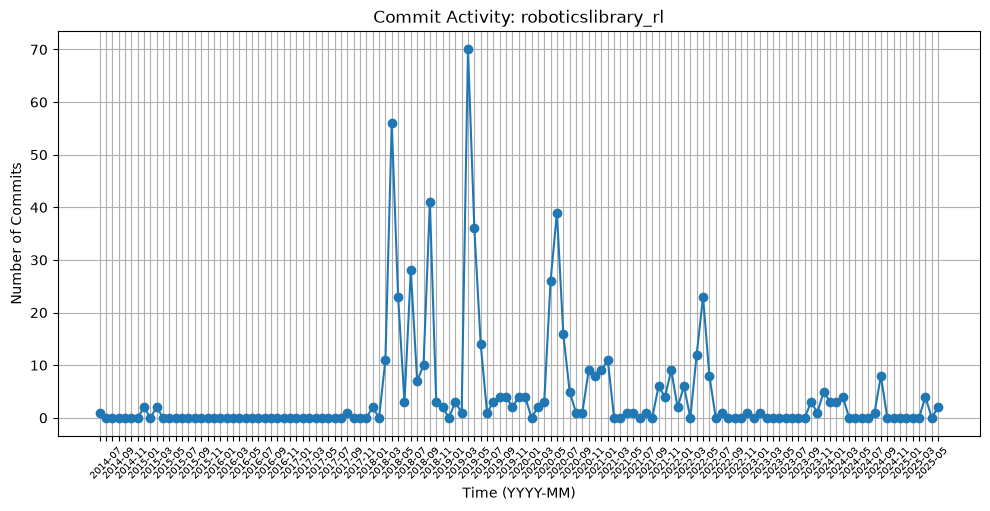

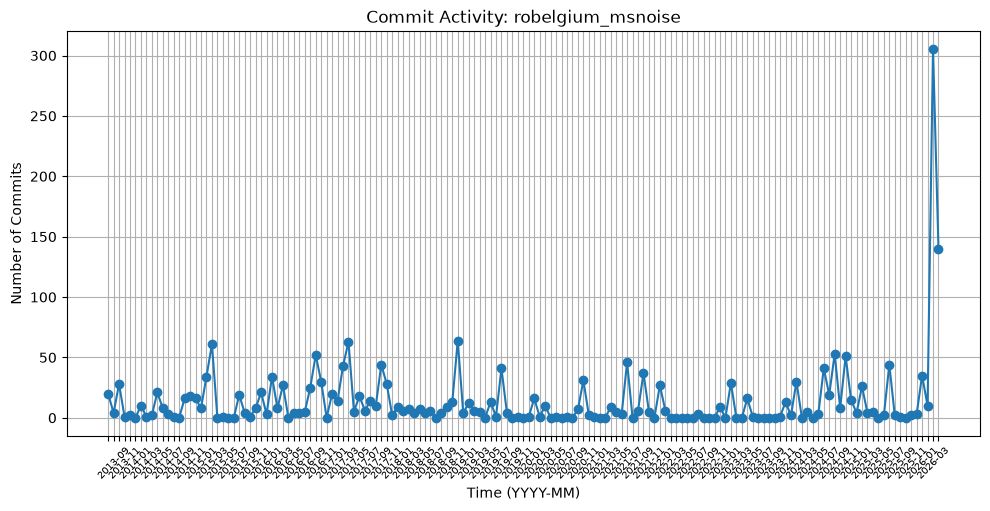

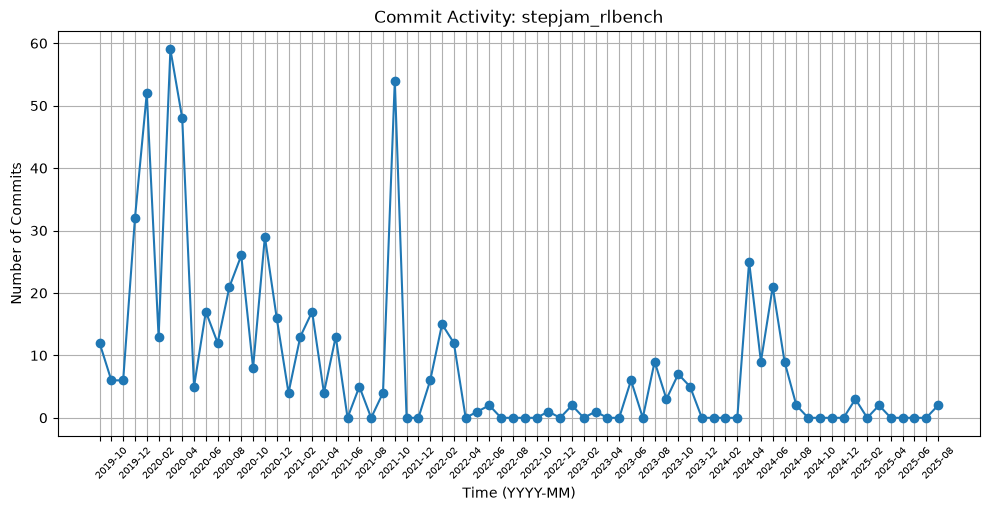

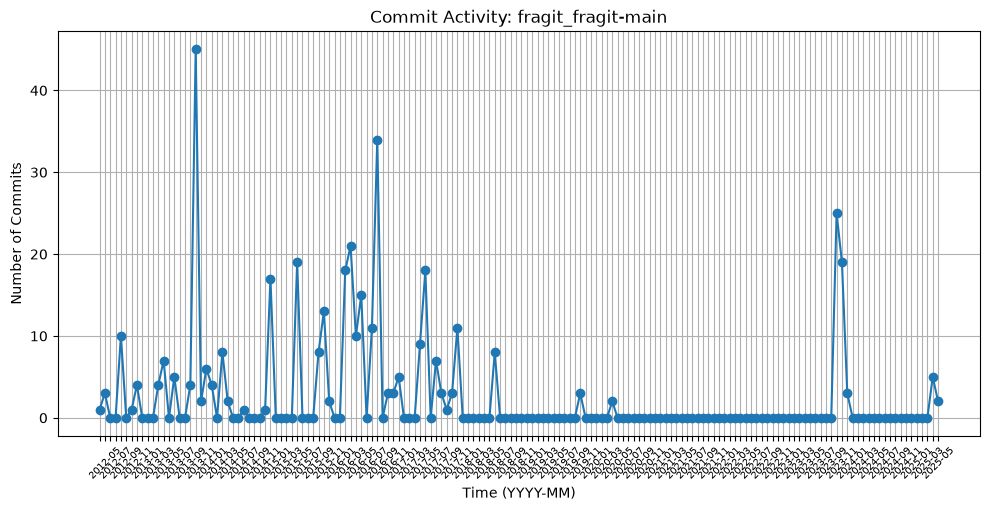

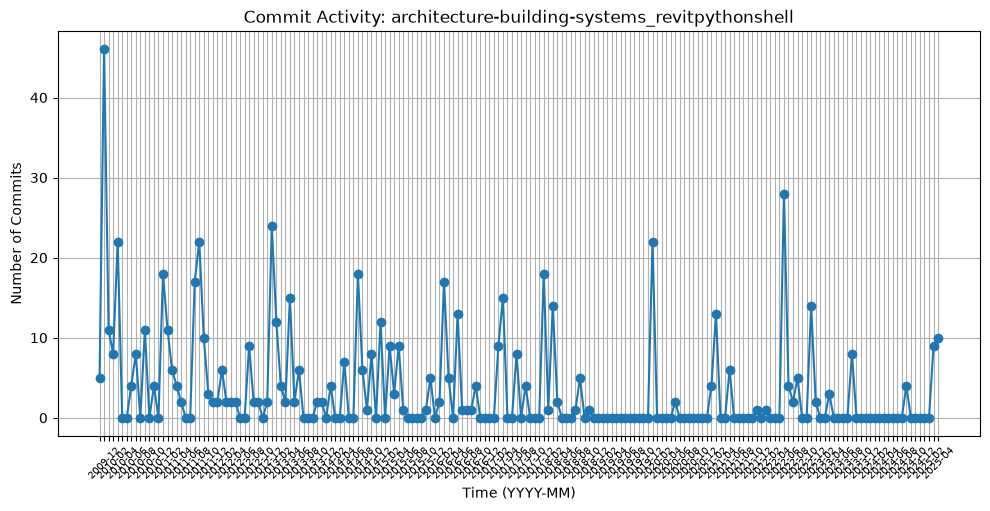

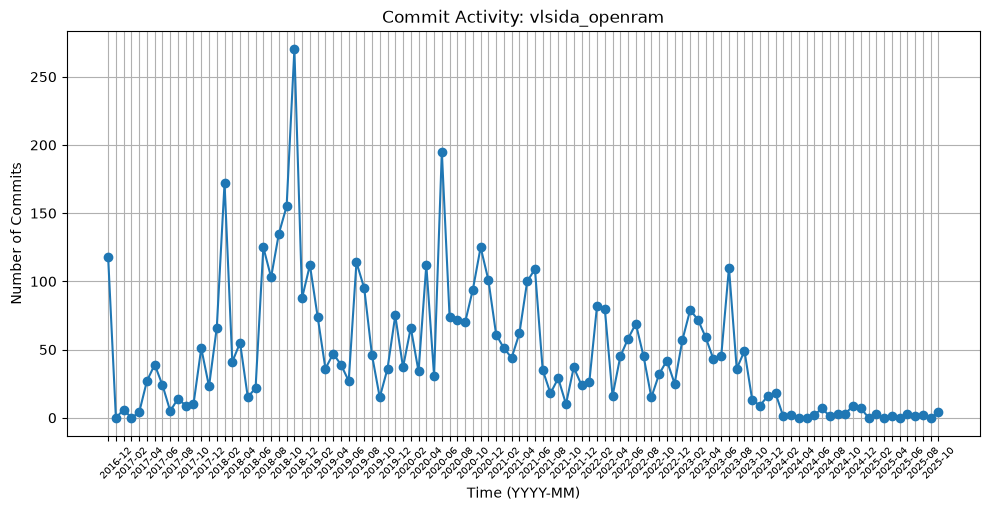

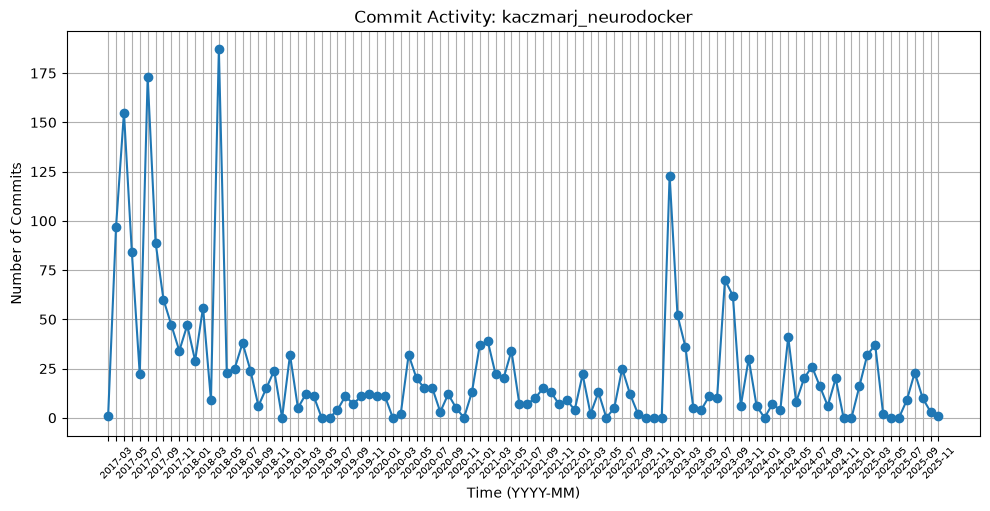

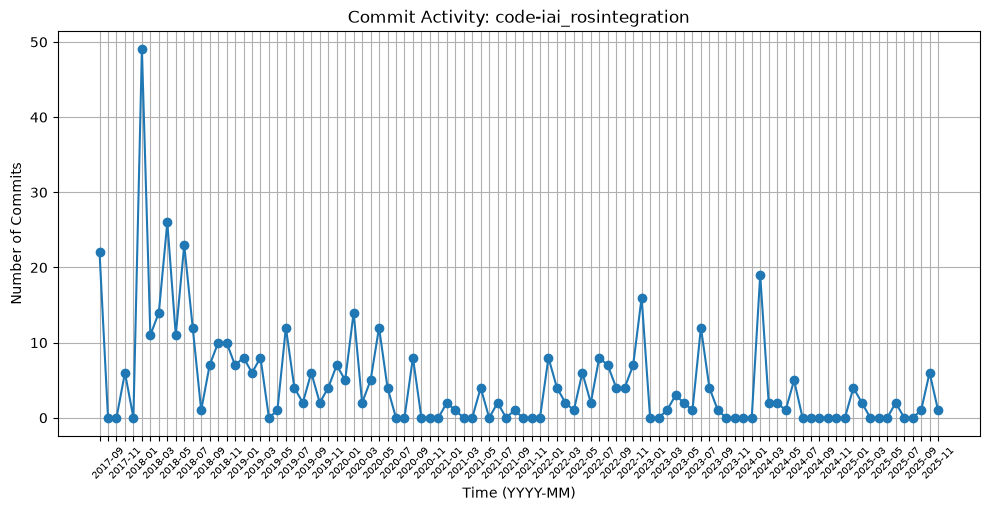

In [3]:
# made into a loop

projects = df['project'].unique()

for prj in projects:
    # prj='worldwidetelescope_pywwt'
    df1 = df[df['project']==prj]
    df2 = df1.groupby('Month').size().reset_index(name='Commits')
    monthly_counts = df2
    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
    full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
    monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
    monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
    
    # saving info
    monthly_counts.drop(columns='time').to_csv("./timeseries/hneel_commits_timeseries_"+prj+".csv", index=False,sep=';', mode='a')
    
    # Plot
    import matplotlib.ticker as ticker
    
    plt.figure(figsize=(10,5))
    plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title("Commit Activity: "+prj)
    plt.grid(True)
    plt.tight_layout()
    ax =  plt.gca()
    for label in ax.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)
    plt.xticks(rotation=45, fontsize=7)
    
    # moved to folder
    plt.savefig("./timeseries/hneel_timeseries_"+prj+".png", dpi=600)
    
    plt.show()
    plt.close()


# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv